# 실습 주제
- 식당 팁(Tip) 예측 모형 생성을 통한 기초 통계 및 데이터 분석 종합 실습

## 실습 목표
- 학습한 전처리 기법과 회귀 분석을 활용하여 Test 데이터 기준 예측 오차(MAPE, Mean Absolute Percentage Error)를 최소화하는 최적의 모형을 구축

## 데이터셋
- seaborn에서 제공하는 tips 데이터셋 (아래에 제공한 코드 이용)

---
## 실습 조건
1. 분석 데이터 로드: 아래 코드를 복사해 데이터를 가져오세요.
2. Target 변수: tip (지불한 팁 금액, 달러)
3. 파생 변수 생성: 주어진 변수를 조합해, 팁 금액에 영향을 미칠 만한 논리적인 파생변수를 최소 2개 이상 생성합니다. (예: 1인당 식사 금액, 주말 여부 등)

4. Data Partition: train_test_split 함수를 사용해 분석용 데이터와 평가용 데이터를 8:2로 분할합니다.
5. 데이터 전처리: 수업 시간에 배운 기법을 활용해 다음 과정을 반드시 포함합니다.
6. 결측치 또는 이상치 탐지 및 처리 (합리적인 기준 적용)
7. 연속형 변수에 대한 분포 확인 및 스케일링 (Min-Max 또는 Standard)
8. 범주형 변수에 대한 One-hot Encoding
9. 회귀 분석 모델: statsmodels.api 라이브러리를 사용합니다.



# 라이브러리 업로드

In [27]:
!sudo apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [28]:
!apt-get -qq install -y fonts-nanum > /dev/null

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# 설치된 나눔고딕을 matplotlib 폰트 매니저에 '직접' 등록
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

## 데이터 분석
- 분석 데이터 로드: 아래 코드를 복사해 데이터를 가져오세요.


In [30]:
data = sns.load_dataset("tips")
df = data.copy()
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [32]:
df.shape

(244, 7)

In [33]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [34]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


- 결측치 존재하지 않음

In [35]:
for col in df.columns:
    print(f"컬럼: {col:15s} | 타입: {str(df[col].dtype):10s} | 고유값 개수: {df[col].nunique()}")

컬럼: total_bill      | 타입: float64    | 고유값 개수: 229
컬럼: tip             | 타입: float64    | 고유값 개수: 123
컬럼: sex             | 타입: category   | 고유값 개수: 2
컬럼: smoker          | 타입: category   | 고유값 개수: 2
컬럼: day             | 타입: category   | 고유값 개수: 4
컬럼: time            | 타입: category   | 고유값 개수: 2
컬럼: size            | 타입: int64      | 고유값 개수: 6


- 변수 종류 7개 / 범주형, 연속형 나눠져있음
- 연속형 변수는 total_bill, tip, size

In [36]:
num_cols = ['total_bill', 'size']
categorical_cols = ['sex', 'smoker', 'day', 'time']

In [37]:
# 범주형 변수를 0과 1로 변환
df_encoded = pd.get_dummies(df, drop_first=True)

# 전체 변수와 tip 간의 상관계수 절댓값 순 정렬
print(df_encoded.corr()['tip'].abs().sort_values(ascending=False))

tip            1.000000
total_bill     0.675734
size           0.489299
day_Sun        0.125114
time_Dinner    0.121629
sex_Female     0.088862
day_Fri        0.055463
smoker_No      0.005929
day_Sat        0.002790
Name: tip, dtype: float64


# 상관 분석

### 종속변수(Target)와 가장 상관성이 높은 2개 변수

=== tip과의 상관계수 ===
tip            1.000000
total_bill     0.675734
size           0.489299
day_Sun        0.125114
time_Dinner    0.121629
day_Sat       -0.002790
smoker_No     -0.005929
day_Fri       -0.055463
sex_Female    -0.088862
Name: tip, dtype: float64


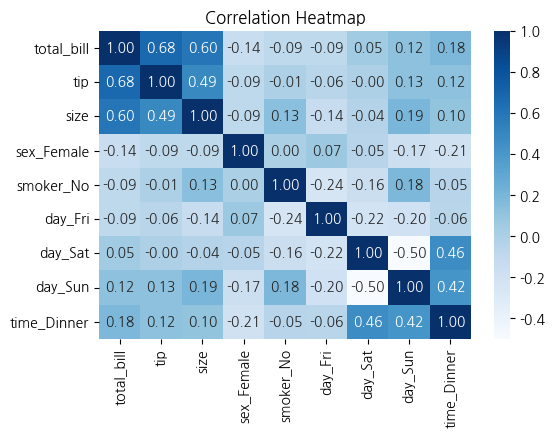

In [38]:
df = pd.get_dummies(df, drop_first=True)
# 3. 전체 변수 간 상관계수 행렬 계산
corr = df.corr()

# 3. tip과의 상관계수 절대값 순으로 정렬하여 상위 변수 확인
print("=== tip과의 상관계수 ===")
print(corr['tip'].sort_values(ascending=False))

# 4. 히트맵 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 설명변수 간 상관성이 가장 높은 2개 Pair

In [39]:
# 2. 타겟(tip)을 제외한 수치형 설명변수 데이터프레임 생성
X_numeric = df.drop(columns=['tip'])

# 3. 상관계수 행렬 계산 및 중복 제거(상삼각 행렬 마스크 적용)
corr_matrix = X_numeric.corr(numeric_only=True)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# 4. 모든 Pair를 데이터프레임 형태로 정리
all_pairs = (
    corr_matrix.where(mask)
    .stack()
    .reset_index()
    .rename(
        columns={'level_0': '변수 1', 'level_1': '변수 2', 0: '상관계수(r)'}
    )
)

# 5. 절댓값 기준 내림차순 정렬
all_pairs['절댓값(|r|)'] = all_pairs['상관계수(r)'].abs()
all_pairs = all_pairs.sort_values(
    by='절댓값(|r|)', ascending=False
).reset_index(drop=True)

# 결과 전체 출력
print("=== 모든 설명변수 Pair 간 상관계수 목록 ===")
display(all_pairs)

=== 모든 설명변수 Pair 간 상관계수 목록 ===


,변수 1,변수 2,상관계수(r),절댓값(|r|)
0,total_bill,size,0.598315,0.598315
1,day_Sat,day_Sun,-0.500682,0.500682
2,day_Sat,time_Dinner,0.462709,0.462709
3,day_Sun,time_Dinner,0.418071,0.418071
4,smoker_No,day_Fri,-0.244316,0.244316
5,day_Fri,day_Sat,-0.216319,0.216319
6,sex_Female,time_Dinner,-0.205231,0.205231
7,day_Fri,day_Sun,-0.195451,0.195451
8,size,day_Sun,0.193054,0.193054
9,total_bill,time_Dinner,0.183118,0.183118


In [40]:
display(all_pairs.head(2))

,변수 1,변수 2,상관계수(r),절댓값(|r|)
0,total_bill,size,0.598315,0.598315
1,day_Sat,day_Sun,-0.500682,0.500682


- 뭔가 요일별로 상세히, 담배여부로 상세히 진행해도 좋을 듯하지만.. 일단 다시 원본으로 가야할 듯

# 데이터 전처리 과정
## 파생변수 생성

- 파생변수를 생성하기 위해 데이터를 더욱 분석해보자
- Target 변수: tip (지불한 팁 금액, 달러)
- 파생 변수 생성: 주어진 변수를 조합해, 팁 금액에 영향을 미칠 만한 논리적인 파생변수를 최소 2개 이상 생성합니다. (예: 1인당 식사 금액, 주말 여부 등)



### 가설 설정
1. 식사 금액이 클수록 팁이 높을 것이다.
2. 주말일 때 팁이 높을 것이다.

우선 기존 변수 설정을 다시 돌려놓자

In [41]:
data = sns.load_dataset("tips")
df = data.copy()

In [42]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [43]:
num_cols = ['total_bill', 'size']
cat_cols = ['sex', 'smoker', 'day', 'time']
all_features = num_cols + cat_cols

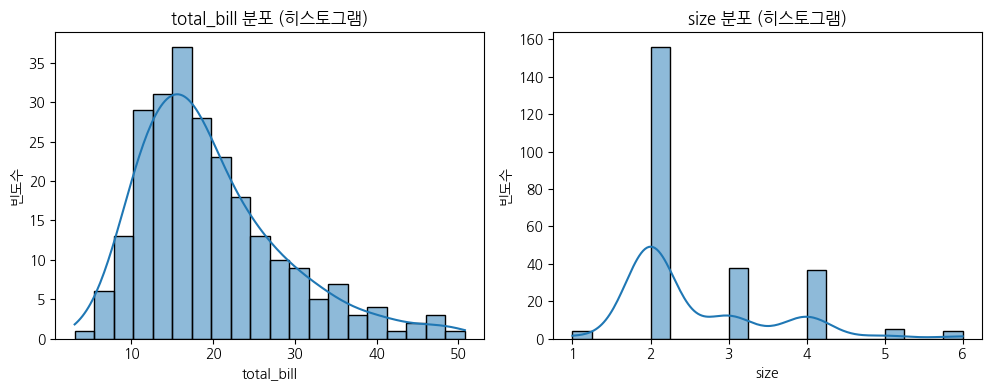

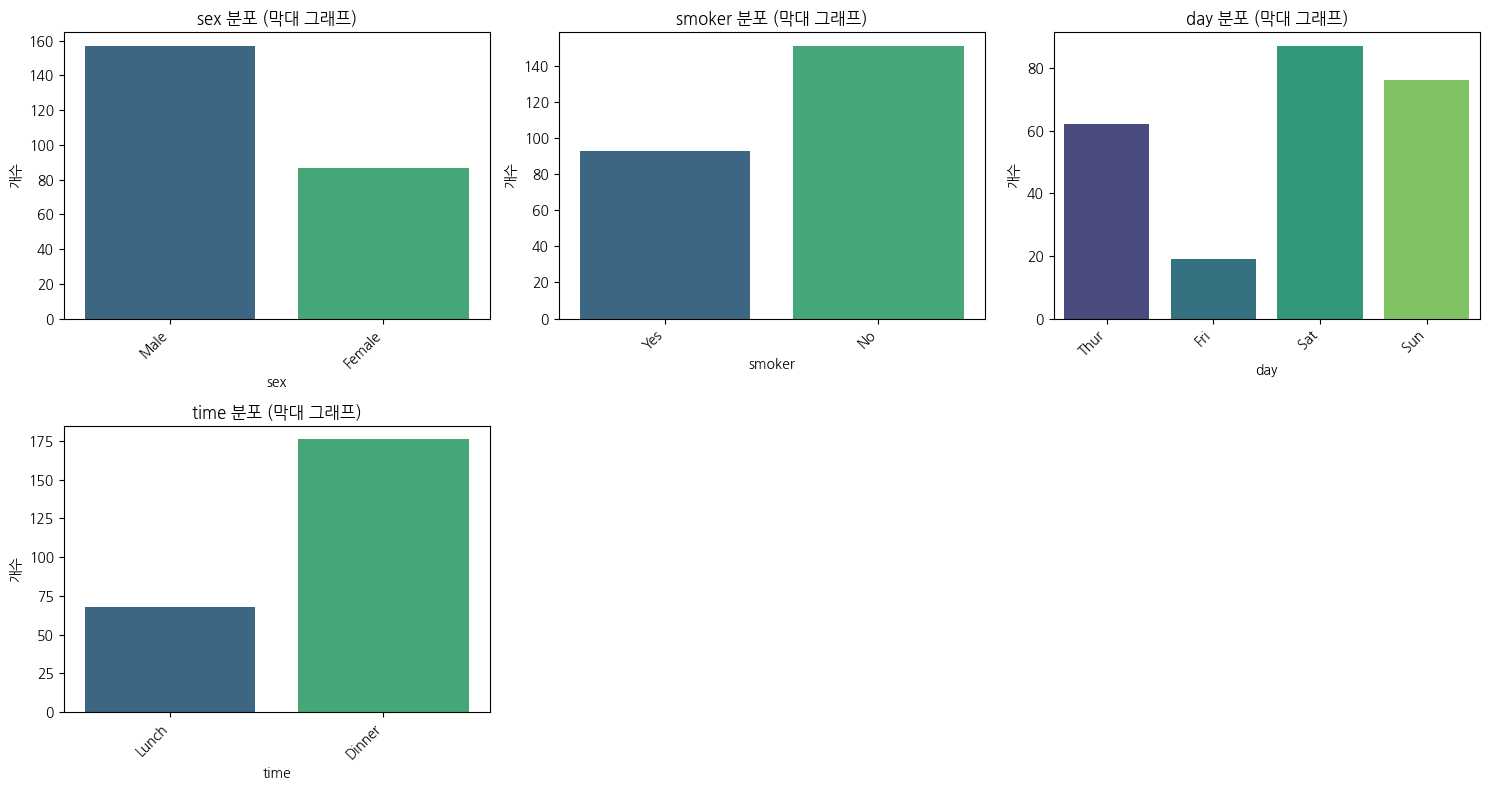

In [44]:
# 연속형 변수 히스토그램 그리기
if num_cols:
    n_num = len(num_cols)
    cols_num = 3
    rows_num = (n_num // cols_num) + (n_num % cols_num > 0)

    plt.figure(figsize=(cols_num * 5, rows_num * 4))
    for i, col in enumerate(num_cols, 1):
        plt.subplot(rows_num, cols_num, i)
        sns.histplot(df[col], kde=True, bins=20)
        plt.title(f'{col} 분포 (히스토그램)')
        plt.xlabel(col)
        plt.ylabel('빈도수')
    plt.tight_layout()
    plt.show()

# 범주형 변수 막대 그래프 그리기
if categorical_cols:
    n_cat = len(categorical_cols)
    cols_cat = 3
    rows_cat = (n_cat // cols_cat) + (n_cat % cols_cat > 0)

    plt.figure(figsize=(cols_cat * 5, rows_cat * 4))
    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(rows_cat, cols_cat, i)
        # FutureWarning를 피하기 위해 hue=col, legend=False 추가
        sns.countplot(x=col, data=df, palette='viridis', hue=col, legend=False)
        plt.title(f'{col} 분포 (막대 그래프)')
        plt.xlabel(col)
        plt.ylabel('개수')
        plt.xticks(rotation=45, ha='right') # 라벨이 겹치지 않도록 회전
    plt.tight_layout()
    plt.show()

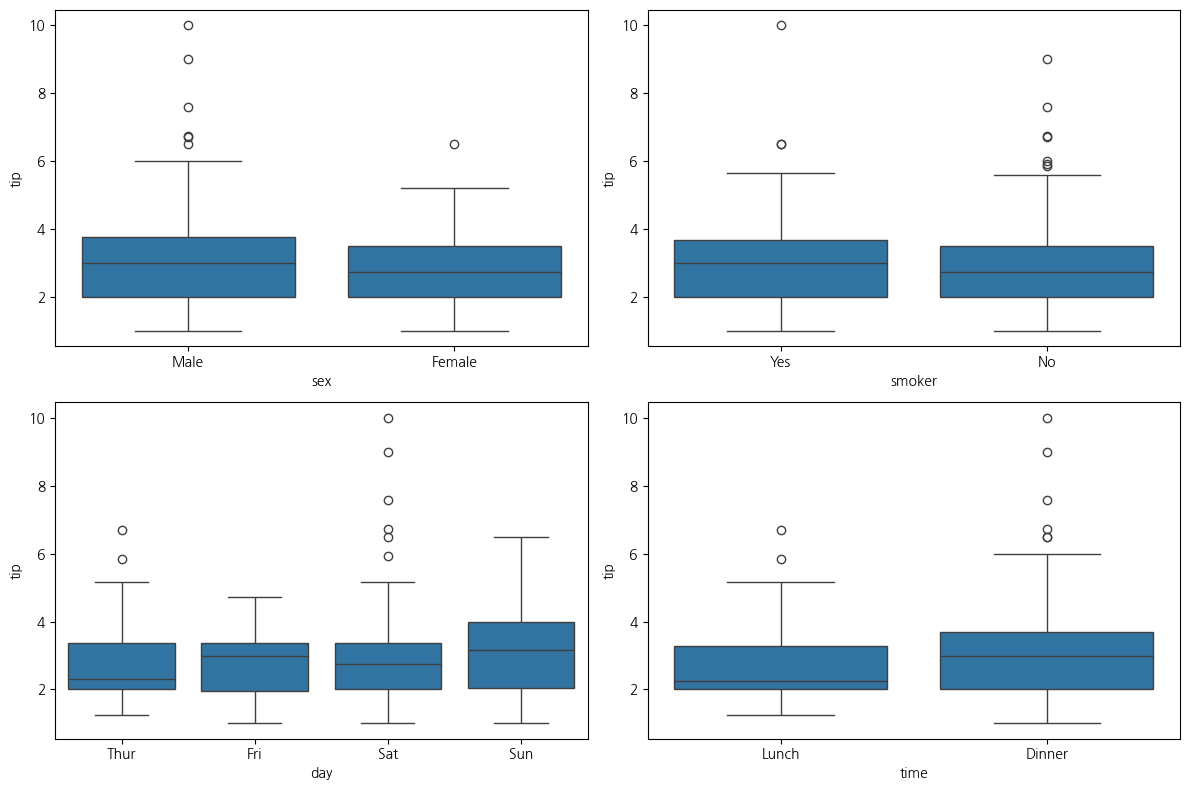

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, x='sex', y='tip', ax=axes[0, 0])
sns.boxplot(data=df, x='smoker', y='tip', ax=axes[0, 1])
sns.boxplot(data=df, x='day', y='tip', ax=axes[1, 0])
sns.boxplot(data=df, x='time', y='tip', ax=axes[1, 1])

plt.tight_layout()
plt.show()

- 이상치로 보이는 값들 있음

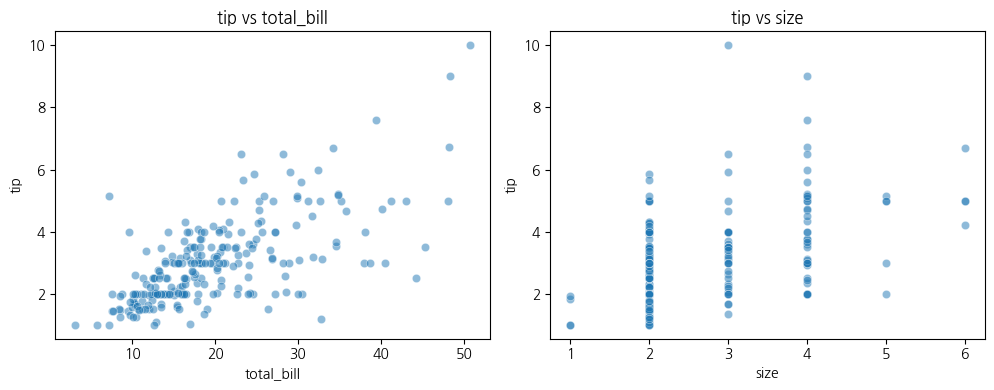

In [46]:
# 연속형 변수 추출
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# 목표변수(tip) 제외
feature_cols = [col for col in num_cols if col != "tip"]

# Scatter Plot
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(data=df, x=col, y="tip", alpha=0.5)
    plt.title(f"tip vs {col}")

plt.tight_layout()
plt.show()

- tip하고 전체 금액하고 약한 관계성이 보임
- tip하고 인원 수하고도 관계 있어보이네

### 종속변수 `tip`과의 상관 분석

`tip`과의 상관관계를 파악하기 위해 모든 수치형 변수 간의 상관 행렬을 계산하고 시각화합니다.

## 그래프 해석
#### total_bill (총 식사 금액)
  - 오른쪽으로 꼬리 있음 주 식사비용은 15~20달러 사이임
  - 최대 값 50달러, 최소값 3달러
#### tip (팁)
  - 팁 역시 오른쪽 꼬리가 보임 평균 팁은 약 3달러
  - 최대 팁 10 달러, 최소 팁 1달러
  - 이상치 확인해보자
#### size (식사 인원)
  - 1~6까지 값으로 주로 2,3명의 손님이 많이 온다.
  - 4명 이상의 그룹 손님은 많이 안옴

#### 분석 결과
  - 대부분 적은 인원의 손님이 온다.
  - 저렴한 식사를 하는 곳이다.
----

# 데이터 전처리

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. 원본 데이터 로드
data = sns.load_dataset('tips')
df = data.copy()

# ----------------------------------------------------
# 1) 결측치/이상치 처리: total_bill IQR 기준 이상치 제거
# ----------------------------------------------------
Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['total_bill'] >= lower_bound) & (df['total_bill'] <= upper_bound)
].reset_index(drop=True)

# ----------------------------------------------------
# 2) 파생변수 생성 (스케일링/인코딩 전 원본 값 기반!)
# ----------------------------------------------------
# - 파생변수 A: 1인당 식사 금액
df['bill_per_person'] = df['total_bill'] / df['size']

# - 파생변수 B: 주말 여부 (Sat, Sun이면 1, 아니면 0)
df['is_weekend'] = df['day'].isin(['Sat', 'Sun']).astype(int)

# ----------------------------------------------------
# 3) Scaling: 연속형 변수 스케일링 (tip 제외)
# ----------------------------------------------------
scaler = StandardScaler()
num_cols = ['total_bill', 'size', 'bill_per_person']
df[num_cols] = scaler.fit_transform(df[num_cols])

# ----------------------------------------------------
# 4) Encoding: 범주형 변수 One-hot Encoding
# ----------------------------------------------------
cat_cols = ['sex', 'smoker', 'day', 'time']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ----------------------------------------------------
# 5) 다중공선성이 높은 변수 제거 (선택)
# ----------------------------------------------------
# bill_per_person 또는 size 중 다중공선성을 완화할 변수 제거
if 'bill_per_person' in df.columns:
    df = df.drop(columns=['bill_per_person'])

print("전처리 완료! 최종 데이터 모양:", df.shape)
display(df.head())

전처리 완료! 최종 데이터 모양: (235, 10)


,total_bill,tip,size,is_weekend,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,-0.243671,1.01,-0.575143,1,True,True,False,False,True,True
1,-1.139581,1.66,0.523708,1,False,True,False,False,True,True
2,0.297916,3.50,0.523708,1,False,True,False,False,True,True
3,0.657627,3.31,-0.575143,1,False,True,False,False,True,True
4,0.780225,3.61,1.622559,1,True,True,False,False,True,True


In [48]:
print("데이터 전처리 완료 후 df의 컬럼 목록:")
print(df.columns.tolist())

데이터 전처리 완료 후 df의 컬럼 목록:
['total_bill', 'tip', 'size', 'is_weekend', 'sex_Female', 'smoker_No', 'day_Fri', 'day_Sat', 'day_Sun', 'time_Dinner']


# 회귀 분석 결과

In [49]:
# 1. Target(y) 및 Independent Features(X) 분리
X = df.drop(columns=['tip'])
y = df['tip']

# 2. Data Partitioning (8:2 분할)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 3. statsmodels OLS 모델을 위한 상수항(Constant) 추가 및 모델 학습
X_train_ols = sm.add_constant(X_train.astype(float))
X_test_ols = sm.add_constant(X_test.astype(float))

model = sm.OLS(y_train, X_train_ols).fit()

# 4. MAPE 계산 함수 정의
def get_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# 5. 각 지표 산출
# ① Test MAPE (OLS 모델의 예측 오차율)
y_pred_test = model.predict(X_test_ols)
test_mape = get_mape(y_test, y_pred_test)

# ② Baseline MAPE (Train 데이터 평균값으로 단순 예측했을 때의 오차율)
y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean())
baseline_mape = get_mape(y_test, y_pred_baseline)

# ③ 통계적으로 유의한 변수 (p-value < 0.05) 추출
pvalues = model.pvalues
significant_vars = pvalues[pvalues < 0.05].index.tolist()

# 6. 결과 정리 및 출력
print("==========================================")
print(f"1) Test MAPE: {test_mape:.2f}%")
print(f"2) Baseline MAPE: {baseline_mape:.2f}%")
print("3) 통계적으로 유의한 변수 (p-value < 0.05):")
for var in significant_vars:
    p_val = pvalues[var]
    print(f"   - {var}: p-value = {p_val:.4f}")
print("==========================================")

# OLS 상세 결과 요약 출력
print("\n[OLS Regression Results Summary]")
print(model.summary())

1) Test MAPE: 32.56%
2) Baseline MAPE: 48.50%
3) 통계적으로 유의한 변수 (p-value < 0.05):
   - const: p-value = 0.0000
   - total_bill: p-value = 0.0000
   - size: p-value = 0.0465

[OLS Regression Results Summary]
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     17.40
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           4.91e-19
Time:                        00:27:00   Log-Likelihood:                -244.40
No. Observations:                 188   AIC:                             506.8
Df Residuals:                     179   BIC:                             535.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
     

- 다중공선성 있음!! 수정해보자 중복 변수 재거 후 다시

In [50]:
# 1. Target(y) 및 Independent Features(X) 분리
# [예시] is_weekend 변수를 남기고 기존 요일 더미 변수를 제거하여 다중공선성 해결하기
X = df.drop(columns=['tip', 'day_Fri', 'day_Sat', 'day_Sun'])
y = df['tip']

# 2. Data Partitioning (8:2 분할)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 3. statsmodels OLS 모델을 위한 상수항(Constant) 추가 및 모델 학습
X_train_ols = sm.add_constant(X_train.astype(float))
X_test_ols = sm.add_constant(X_test.astype(float))

model = sm.OLS(y_train, X_train_ols).fit()

# 4. MAPE 계산 함수 정의
def get_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


# 5. 각 지표 산출
# ① Test MAPE (OLS 모델의 예측 오차율)
y_pred_test = model.predict(X_test_ols)
test_mape = get_mape(y_test, y_pred_test)

# ② Baseline MAPE (Train 데이터 평균값으로 단순 예측했을 때의 오차율)
y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean())
baseline_mape = get_mape(y_test, y_pred_baseline)

# ③ 통계적으로 유의한 변수 (p-value < 0.05) 추출
pvalues = model.pvalues
significant_vars = pvalues[pvalues < 0.05].index.tolist()

# 6. 결과 정리 및 출력
print("==========================================")
print(f"1) Test MAPE: {test_mape:.2f}%")
print(f"2) Baseline MAPE: {baseline_mape:.2f}%")
print("3) 통계적으로 유의한 변수 (p-value < 0.05):")
for var in significant_vars:
    p_val = pvalues[var]
    print(f"   - {var}: p-value = {p_val:.4f}")
print("==========================================")

# OLS 상세 결과 요약 출력
print("\n[OLS Regression Results Summary]")
print(model.summary())

1) Test MAPE: 33.80%
2) Baseline MAPE: 48.50%
3) 통계적으로 유의한 변수 (p-value < 0.05):
   - const: p-value = 0.0000
   - total_bill: p-value = 0.0000
   - size: p-value = 0.0282

[OLS Regression Results Summary]
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     22.94
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           4.79e-20
Time:                        00:27:00   Log-Likelihood:                -245.30
No. Observations:                 188   AIC:                             504.6
Df Residuals:                     181   BIC:                             527.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
     

## 나름 잘만들어짐!